In [ ]:
import pandas as pd 

human_vqa = pd.read_csv('/home/work/yuna/HPA/evaluation/analysis/processed_results/human_vqa.csv') 
qids = human_vqa.question_id.unique().astype(int)
human_vqa.head()   

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Loading VQA annotations from /home/work/yuna/VLMEval/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations


In [ ]:
mms = pd.read_csv('./vqa_quadrants.csv')  
mms.groupby("cc_quadrant")["MG"].mean() 

cc_quadrant
Human-Only        71.304348
Model-Only        15.833333
Shared Correct     8.978468
Shared Wrong      63.872275
Name: MG, dtype: float64

In [ ]:
quad_stat 

,cc_quadrant,mean,median,n,count,fraction
0,Human-Only,71.304348,70.000,23,23,0.061497
1,Model-Only,15.833333,19.995,60,60,0.160428
2,Shared Correct,8.978468,0.000,124,124,0.331551
3,Shared Wrong,63.872275,70.000,167,167,0.446524


### Does alignment with human hallucination structure under blind conditions predict grounded performance?

Pearson $r$ = -0.164 ($R^2$ = 0.027) | Spearman $\rho$ = -0.030


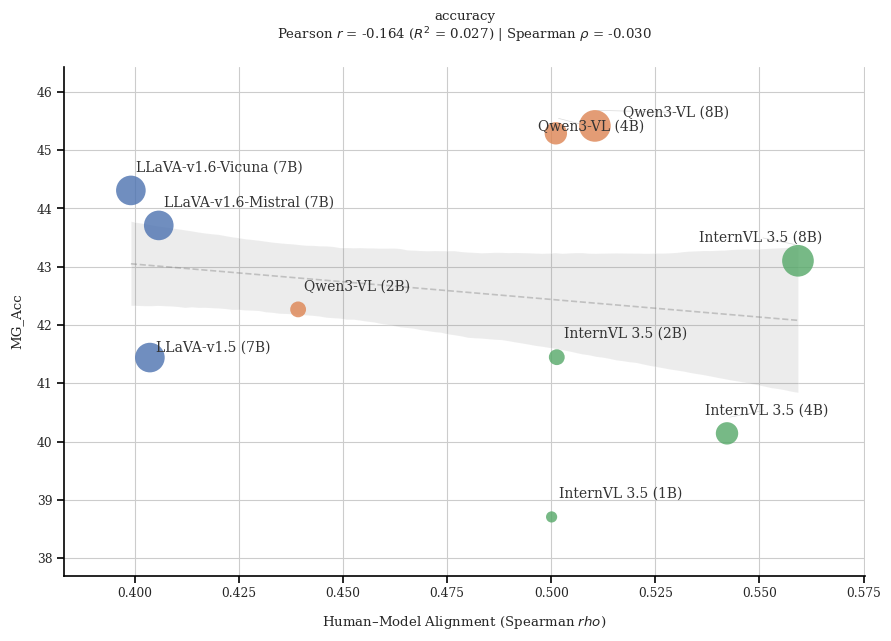

Pearson $r$ = -0.673 ($R^2$ = 0.453) | Spearman $\rho$ = -0.527


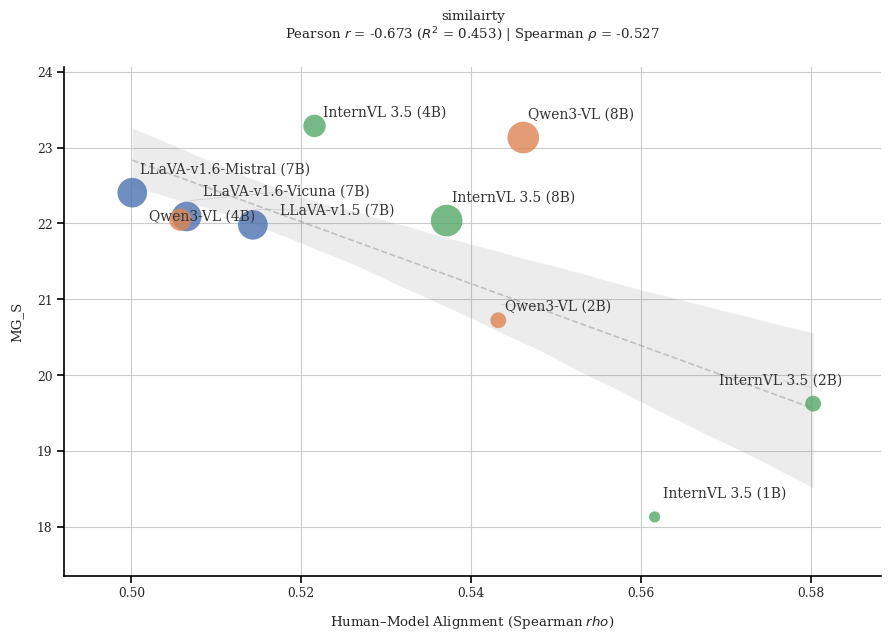

In [ ]:

pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
df = calculate_mg(vqa_5k, filename='vqa_5k').groupby(['model']).mean(numeric_only=True).reset_index()  
pcorr = pd.merge(pcorr, df, on=['model']) 
pcorr = pcorr[['model', 'acc_corr', 'sim_corr', 'MG_Acc', 'MG_S']]
pcorr['family'] = pcorr['model'].map(get_family)
pcorr['model_size'] = pcorr['model'].map(parse_size) 

scatterplot(pcorr, x_col='acc_corr', y_col='MG_Acc', title='accuracy') 
scatterplot(pcorr, x_col='sim_corr', y_col='MG_S', title='similairty') 